# 07 — Interpretabilidade com SHAP + Drift Val → Aplicação

**Objetivo:** Três análises em sequência:

1. **SHAP global** — ranking de importância e efeito por feature (beeswarm, dependence)
2. **Explicações individuais** — waterfall para os 3 colaboradores de maior risco no val por grupo (ferramenta direta para o RH)
3. **Drift val → aplicação** — comparar distribuição de features e de scores entre val (Jun–Ago/2025) e aplicação (Set–Dez/2025) antes de usar o modelo

---

| Entrada | Descrição |
|---|---|
| `models/{grupo}/best_model_tuned.joblib` | Modelo tunado (saída do 06) |
| `models/{grupo}/tuning_metadata.json` | Threshold e metadados |
| `data/processed/feature_selection/{grupo}/selected_features.json` | Features canônicas |
| `data/processed/splits/{grupo}/val.parquet` | Split de validação |
| `data/gold/base_features_val.parquet` | Val pré-escala (drift features) |
| `data/gold/base_features_apl.parquet` | Aplicação pré-escala (drift features) |

| Saída | Descrição |
|---|---|
| `reports/shap/{grupo}/summary_bar.png` | Importância média \|SHAP\| (bar) |
| `reports/shap/{grupo}/summary_beeswarm.png` | Distribuição SHAP (beeswarm) |
| `reports/shap/{grupo}/dependence_top3.png` | Dependence plots top-3 |
| `reports/shap/{grupo}/waterfall_top_risk.png` | Waterfall top-3 de maior risco |
| `reports/figures/{grupo}/drift_val_apl.png` | Drift features + distribuição de scores |
| `reports/shap/{grupo}/shap_values.npy` | SHAP values brutos |
| `reports/shap/{grupo}/shap_feature_importance.json` | Ranking importância |

## 1 · Setup & Configuração

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import shap
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

os.environ["OMP_NUM_THREADS"]      = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"]      = "2"

print(f"shap {shap.__version__}  ·  numpy {np.__version__}  ·  pandas {pd.__version__}")
print(f"Execução: {datetime.now():%Y-%m-%d %H:%M}")


shap 0.51.0  ·  numpy 2.3.5  ·  pandas 2.3.3
Execução: 2026-04-27 18:14


In [2]:
# ════════════════════════════════════════════════════════════════
# CONFIGURAÇÃO
# ════════════════════════════════════════════════════════════════
PROJECT_ROOT = Path.cwd().parent
DATA_SPLITS  = PROJECT_ROOT / "data" / "processed" / "splits"
MODELS_DIR   = PROJECT_ROOT / "models"
SHAP_DIR     = PROJECT_ROOT / "reports" / "shap"

GRUPOS = ["Vendas", "Transporte", "Fábrica"]

# Amostra máxima para cálculo de SHAP (TreeExplainer é rápido, mas limitar evita OOM)
MAX_SHAP_SAMPLES = 1000

print(f"Grupos   : {GRUPOS}")
print(f"Max amostras SHAP : {MAX_SHAP_SAMPLES}")
print(f"Execução : {datetime.now():%Y-%m-%d %H:%M}")


Grupos   : ['Vendas', 'Transporte', 'Fábrica']
Max amostras SHAP : 1000
Execução : 2026-04-27 18:14


## 2 · SHAP por Grupo


GRUPO: Vendas


  Modelo : LightGBM  |  60 features
  Amostras para SHAP : 1000


  SHAP values shape : (1000, 60)
  Top-3 features: ['vl_dias_menos_6_horas_med_3m', 'vl_tempo_empresa', 'vl_falta_horas_med_6m_bin']


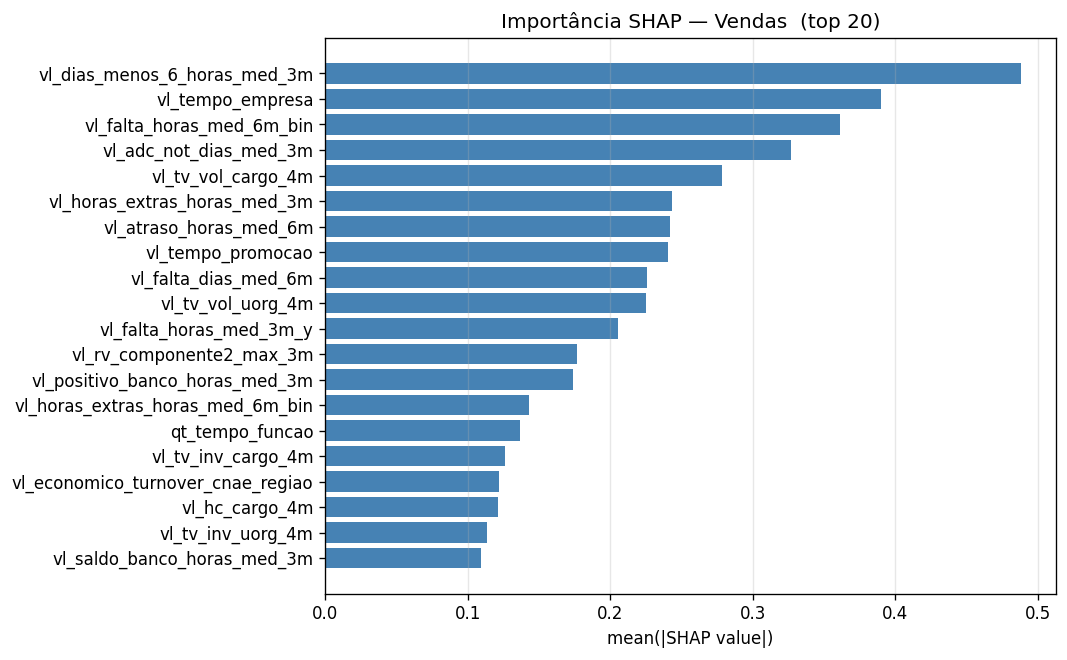

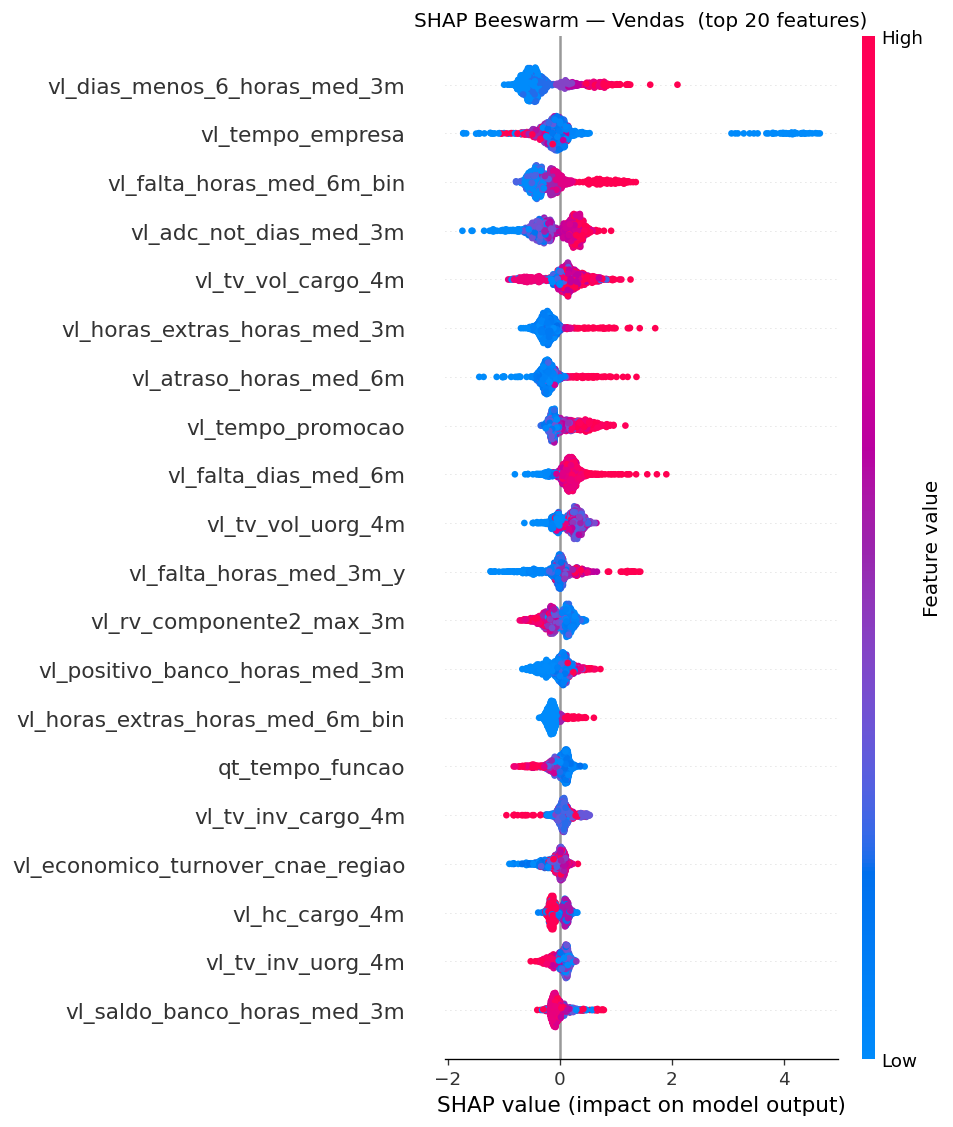

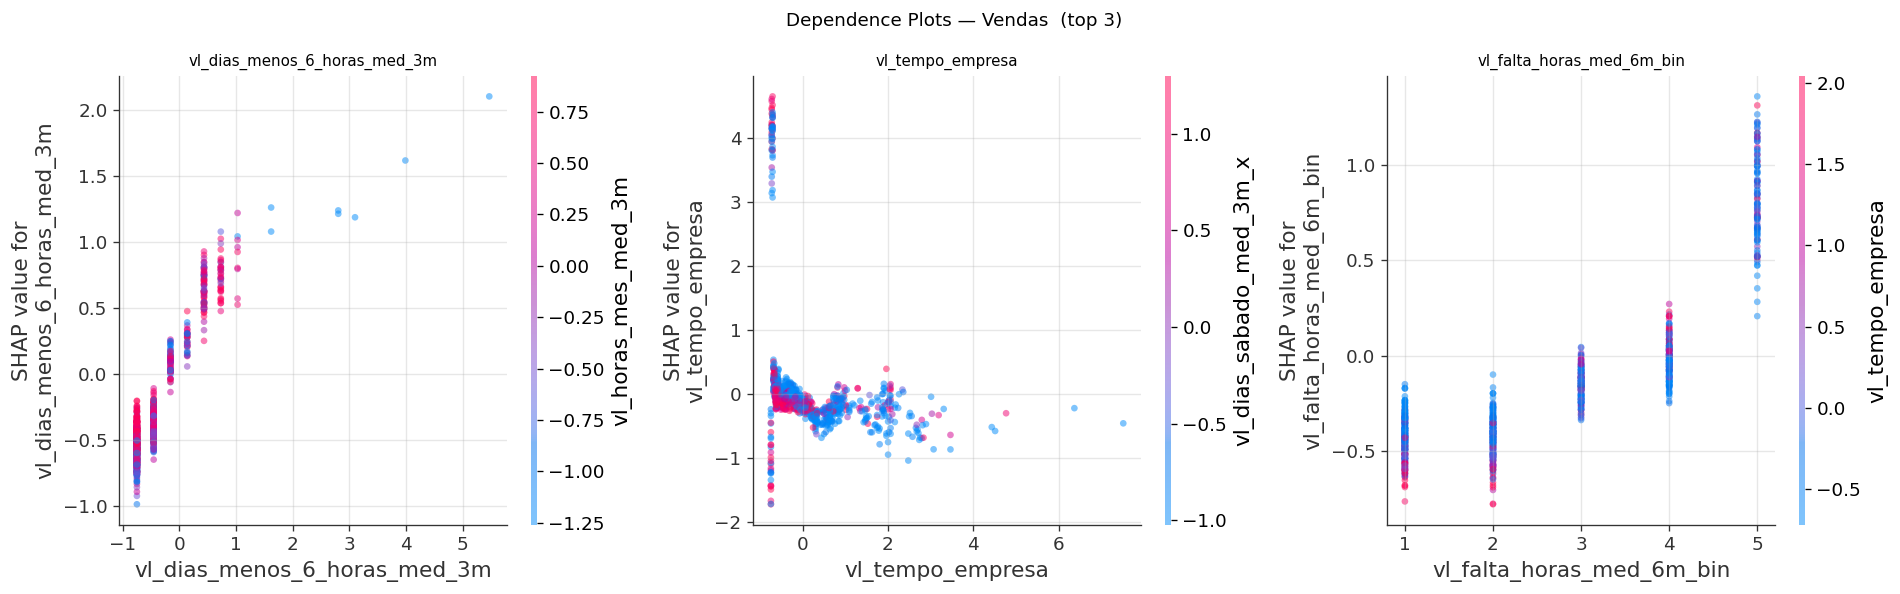

  ✓ summary_bar | beeswarm | dependence_top3 | shap_values.npy | importance.json

GRUPO: Transporte
  Modelo : LightGBM  |  46 features
  Amostras para SHAP : 1000


  SHAP values shape : (1000, 46)
  Top-3 features: ['vl_horas_extras_horas_med_3m', 'vl_dias_menos_6_horas_med_3m', 'vl_atraso_horas_med_6m_bin']


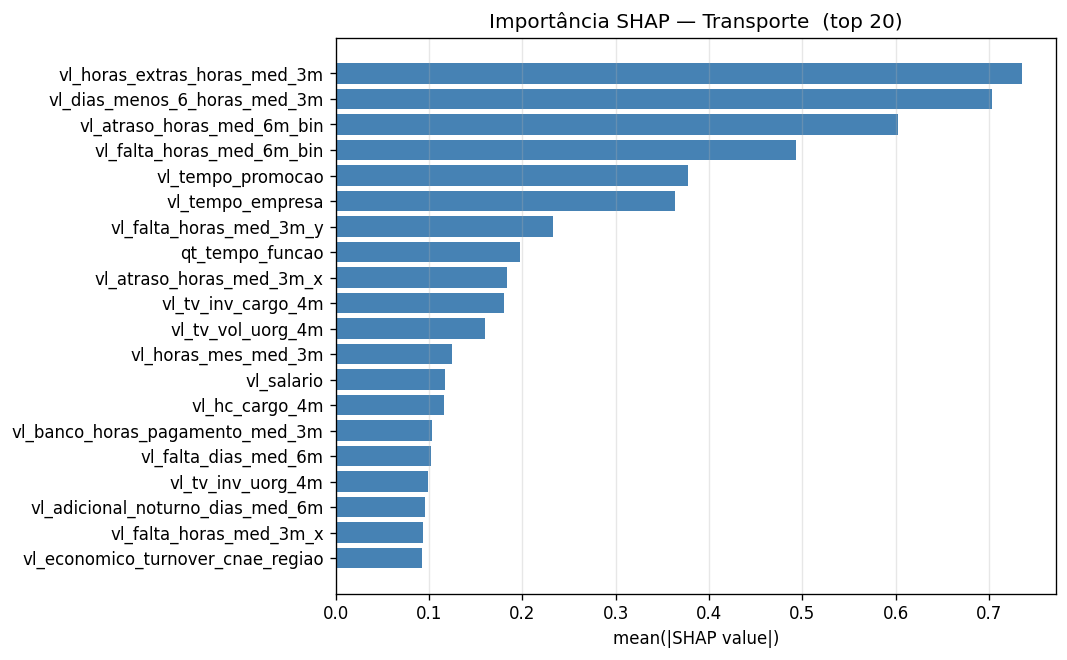

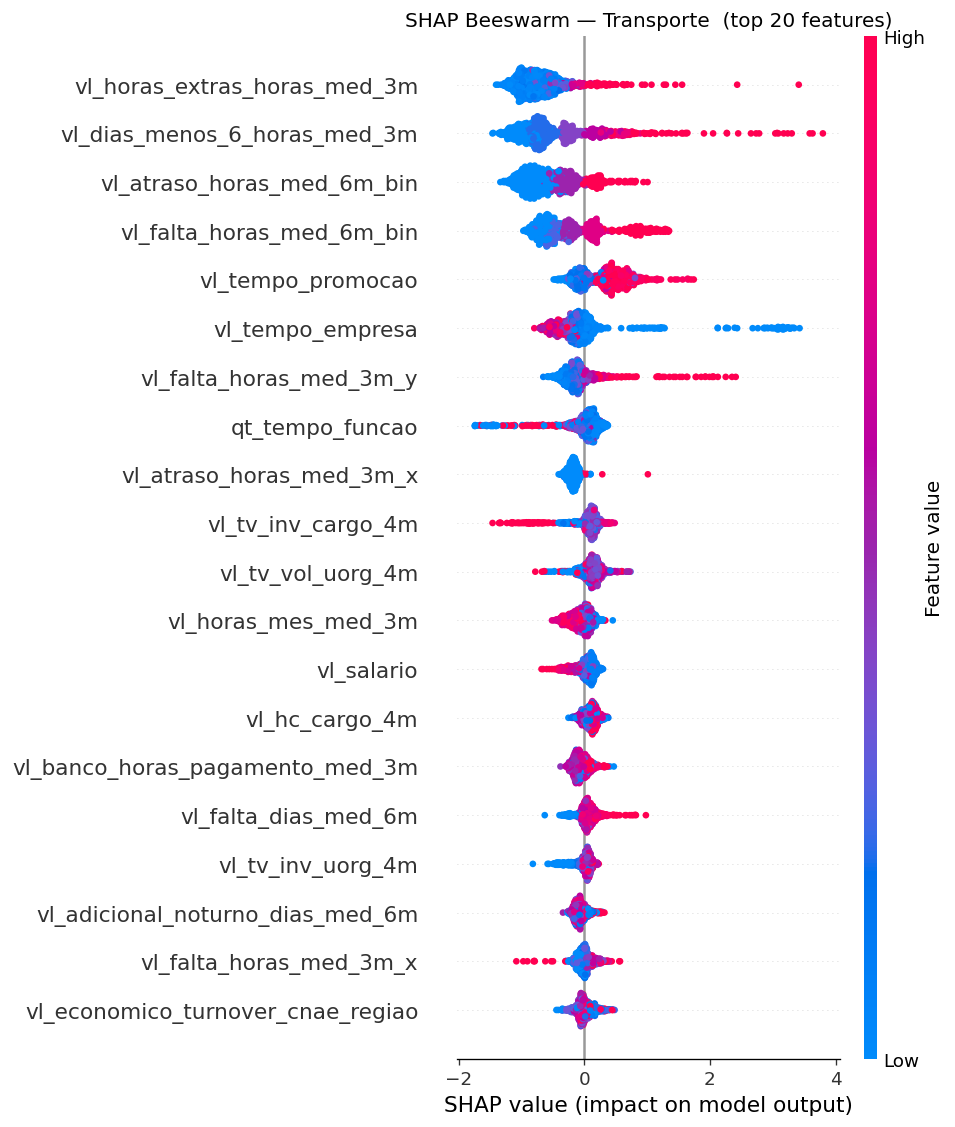

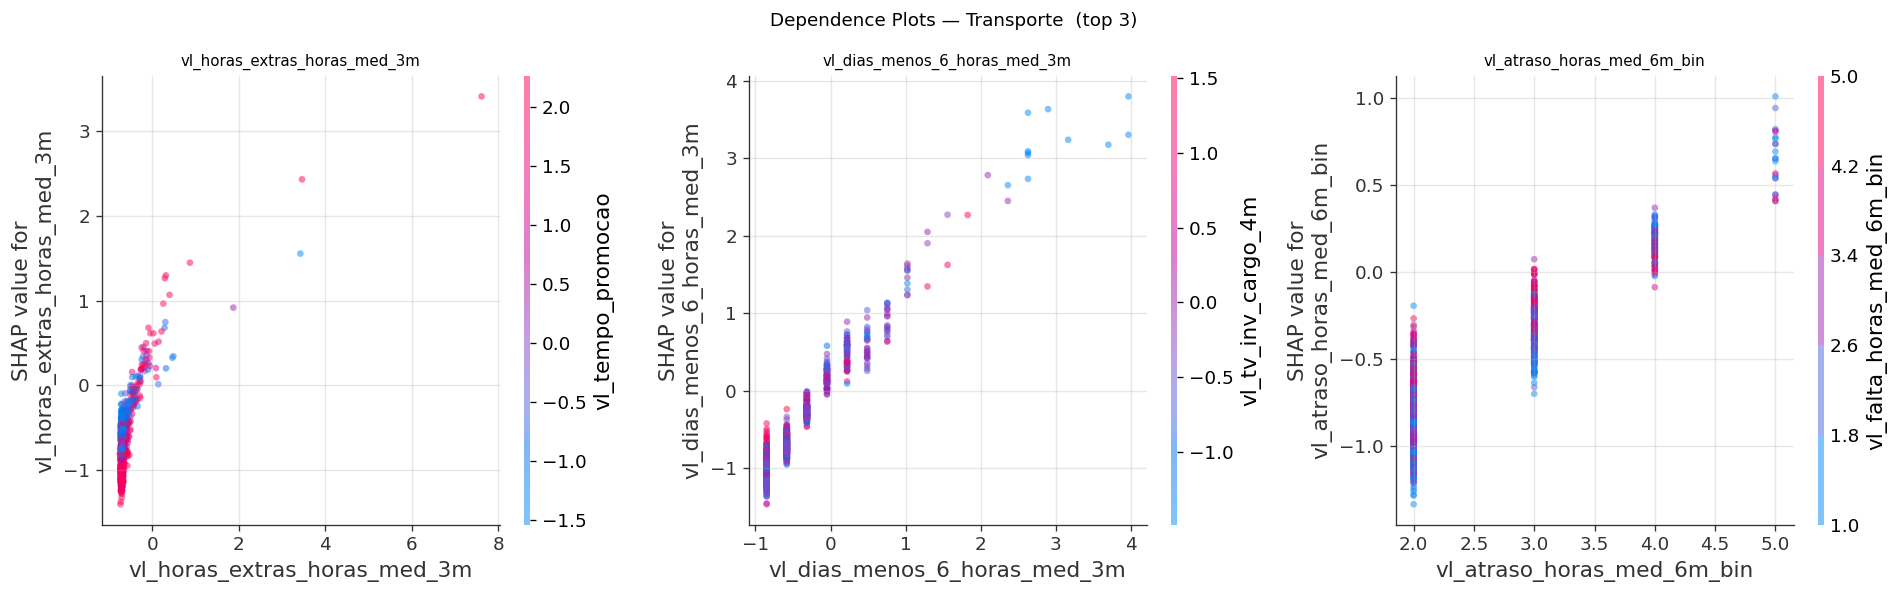

  ✓ summary_bar | beeswarm | dependence_top3 | shap_values.npy | importance.json

GRUPO: Fábrica
  Modelo : XGBoost  |  56 features
  Amostras para SHAP : 1000


  SHAP values shape : (1000, 56)
  Top-3 features: ['vl_tempo_promocao', 'vl_idade', 'vl_atraso_horas_med_6m']


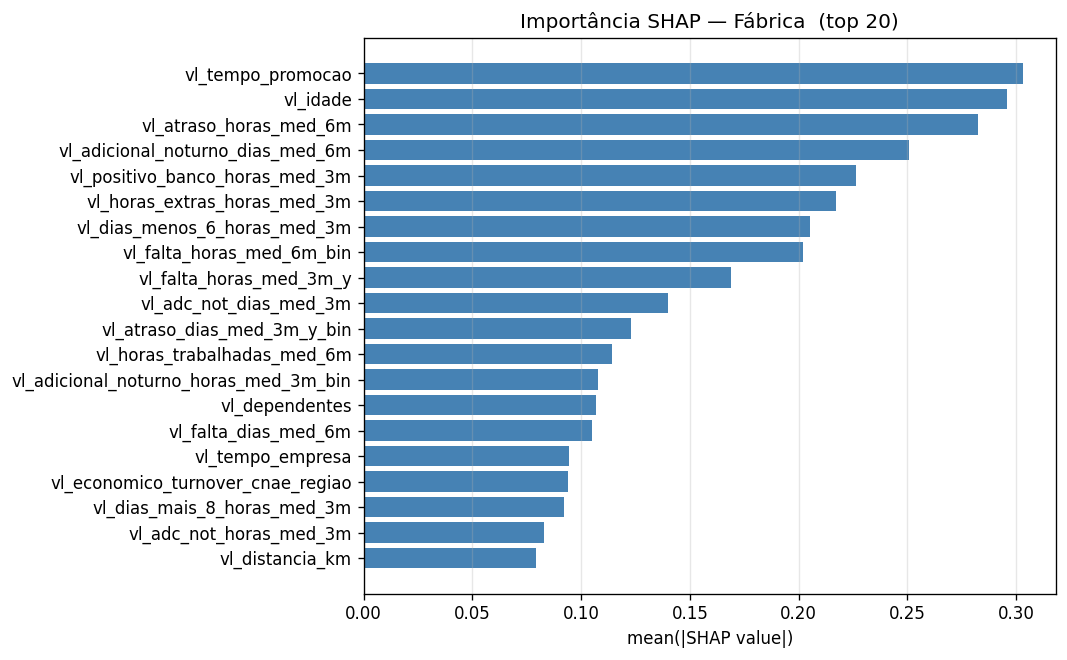

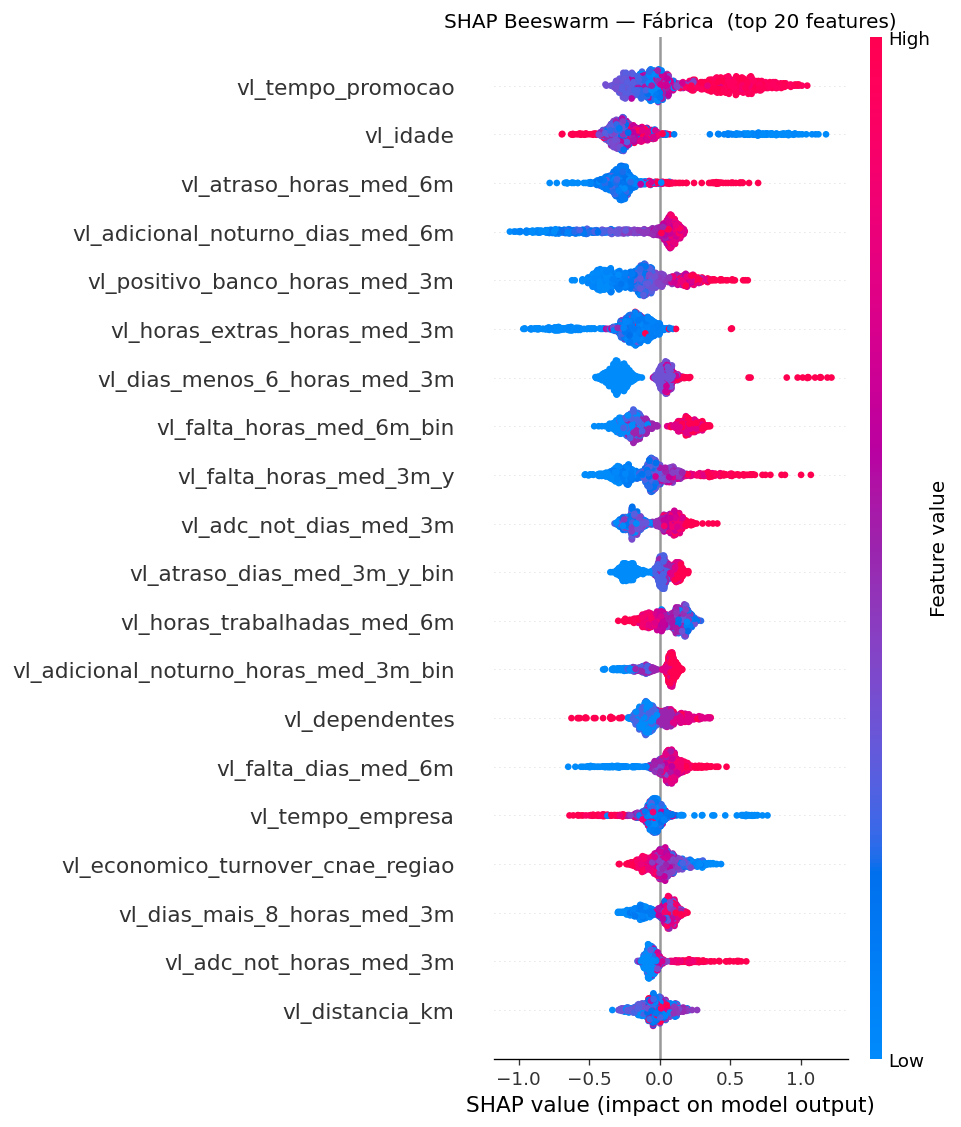

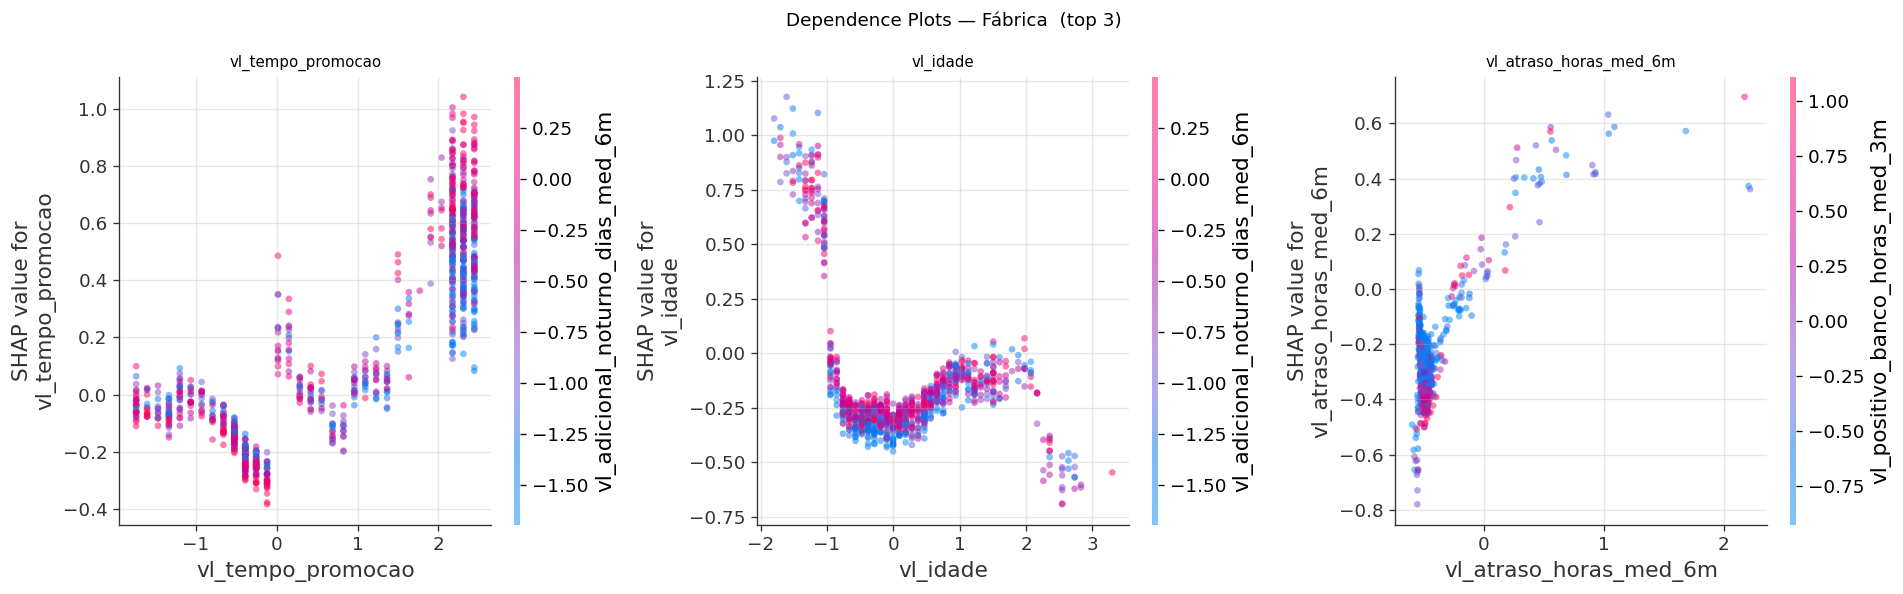

  ✓ summary_bar | beeswarm | dependence_top3 | shap_values.npy | importance.json

✓ SHAP concluído para 3 grupos


In [3]:
FS_DIR = PROJECT_ROOT / "data" / "processed" / "feature_selection"
shap_summary = []

for GRUPO in GRUPOS:
    print(f"\n{'='*65}")
    print(f"GRUPO: {GRUPO}")
    print('='*65)

    grupo_shap   = SHAP_DIR / GRUPO
    grupo_shap.mkdir(parents=True, exist_ok=True)

    # ── Carregar modelo e metadados ───────────────────────────
    # Fonte canônica: selected_features.json (independente do tuning)
    FEATURES = json.loads(
        (FS_DIR / GRUPO / "selected_features.json").read_text(encoding="utf-8")
    )["selected_features"]
    meta_05    = json.loads((MODELS_DIR / GRUPO / "model_metadata.json").read_text(encoding="utf-8"))
    meta_tuned = json.loads((MODELS_DIR / GRUPO / "tuning_metadata.json").read_text(encoding="utf-8"))

    COL_TARGET = meta_05["col_target"]
    MODEL_NAME = meta_05["modelo"]
    model      = joblib.load(MODELS_DIR / GRUPO / "best_model_tuned.joblib")
    print(f"  Modelo : {MODEL_NAME}  |  {len(FEATURES)} features")

    # ── Carregar val (base para SHAP) ────────────────────────
    df_val = pd.read_parquet(DATA_SPLITS / GRUPO / "val.parquet")
    X_val  = df_val[FEATURES].copy()
    y_val  = df_val[COL_TARGET].copy()

    # Amostrar se necessário
    if len(X_val) > MAX_SHAP_SAMPLES:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(X_val), size=MAX_SHAP_SAMPLES, replace=False)
        X_shap = X_val.iloc[idx].reset_index(drop=True)
    else:
        X_shap = X_val.reset_index(drop=True)
    print(f"  Amostras para SHAP : {len(X_shap)}")

    # ── Calcular SHAP values (TreeExplainer) ─────────────────
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)

    # Normalizar formato para array 2D (amostras × features)
    if isinstance(shap_values, list):
        sv = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        sv = shap_values[:, :, 1]
    else:
        sv = shap_values
    print(f"  SHAP values shape : {sv.shape}")

    # ── Importância média |SHAP| ──────────────────────────────
    mean_abs_shap = np.abs(sv).mean(axis=0)
    importance_df = pd.DataFrame({
        "feature"      : FEATURES,
        "mean_abs_shap": mean_abs_shap,
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    top3 = importance_df["feature"].head(3).tolist()
    print(f"  Top-3 features: {top3}")

    # Salvar ranking como JSON
    with open(grupo_shap / "shap_feature_importance.json", "w", encoding="utf-8") as f:
        json.dump(importance_df.to_dict(orient="records"), f, indent=2, ensure_ascii=False)

    # Salvar SHAP values brutos
    np.save(grupo_shap / "shap_values.npy", sv)

    # ── Plot 1: Summary bar ───────────────────────────────────
    top_n = min(20, len(FEATURES))
    imp_top = importance_df.head(top_n)
    fig, ax = plt.subplots(figsize=(9, max(5, top_n * 0.28)))
    ax.barh(imp_top["feature"][::-1], imp_top["mean_abs_shap"][::-1], color="steelblue")
    ax.set(xlabel="mean(|SHAP value|)", title=f"Importância SHAP — {GRUPO}  (top {top_n})")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(grupo_shap / "summary_bar.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

    # ── Plot 2: Beeswarm ──────────────────────────────────────
    feat_order  = importance_df.head(top_n)["feature"].tolist()
    sv_bees     = sv[:, [FEATURES.index(f) for f in feat_order]]
    ev = explainer.expected_value
    base_val = float(np.asarray(ev).flat[-1]) if not np.isscalar(ev) else float(ev)

    shap_exp = shap.Explanation(
        values=sv_bees,
        base_values=np.full(len(X_shap), base_val),
        data=X_shap[feat_order].values,
        feature_names=feat_order,
    )
    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.38)))
    shap.plots.beeswarm(shap_exp, max_display=top_n, show=False)
    plt.title(f"SHAP Beeswarm — {GRUPO}  (top {top_n} features)")
    plt.tight_layout()
    plt.savefig(grupo_shap / "summary_beeswarm.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

    # ── Plot 3: Dependence plots — top 3 ─────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, feat in zip(axes, top3):
        shap.dependence_plot(
            FEATURES.index(feat), sv, X_shap,
            feature_names=FEATURES, ax=ax, show=False, alpha=0.5,
        )
        ax.set_title(feat, fontsize=9); ax.grid(alpha=0.3)
    fig.suptitle(f"Dependence Plots — {GRUPO}  (top 3)", fontsize=11)
    plt.tight_layout()
    plt.savefig(grupo_shap / "dependence_top3.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

    print(f"  ✓ summary_bar | beeswarm | dependence_top3 | shap_values.npy | importance.json")

    shap_summary.append({
        "Grupo"  : GRUPO,
        "Modelo" : MODEL_NAME,
        "N_shap" : len(X_shap),
        "Top-1"  : top3[0],
        "Top-2"  : top3[1],
        "Top-3"  : top3[2],
    })

print(f"\n{'='*65}")
print(f"✓ SHAP concluído para {len(GRUPOS)} grupos")
print(f"{'='*65}")


## 3 · Explicações Individuais — Waterfall (Top-3 Risco)

Waterfall plot para os **3 colaboradores de maior probabilidade prevista** no val de cada grupo.  
Cada barra representa a contribuição marginal de uma feature: vermelho empurra para cima (mais risco), azul para baixo.



GRUPO: Vendas


  #1 maior risco  →  prob=0.9994  (ALTO)


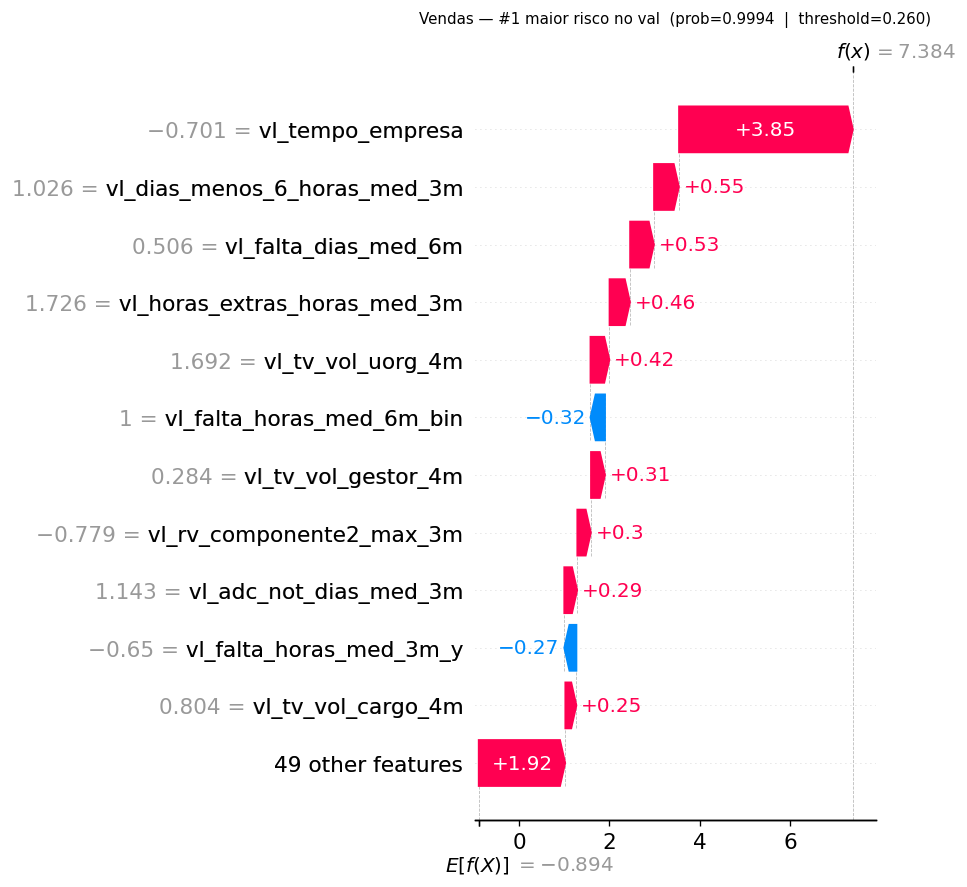

     ✓ Salvo: reports\shap\Vendas\waterfall_top1_risk.png
  #2 maior risco  →  prob=0.9992  (ALTO)


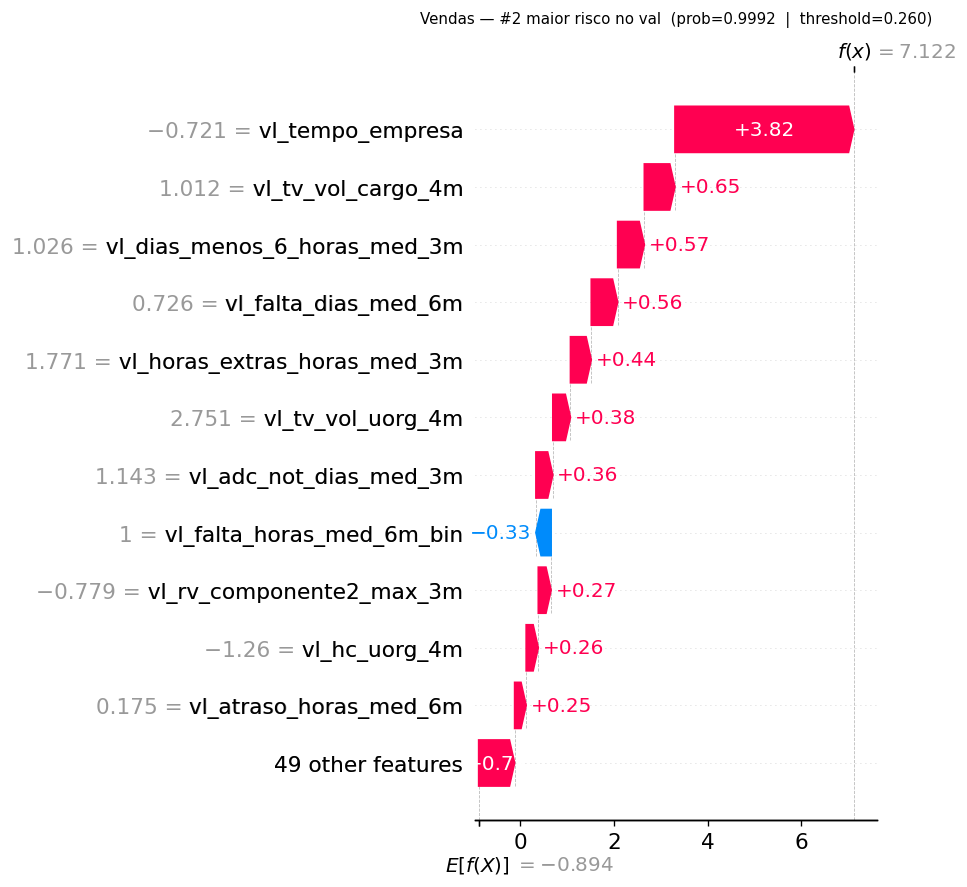

     ✓ Salvo: reports\shap\Vendas\waterfall_top2_risk.png
  #3 maior risco  →  prob=0.9992  (ALTO)


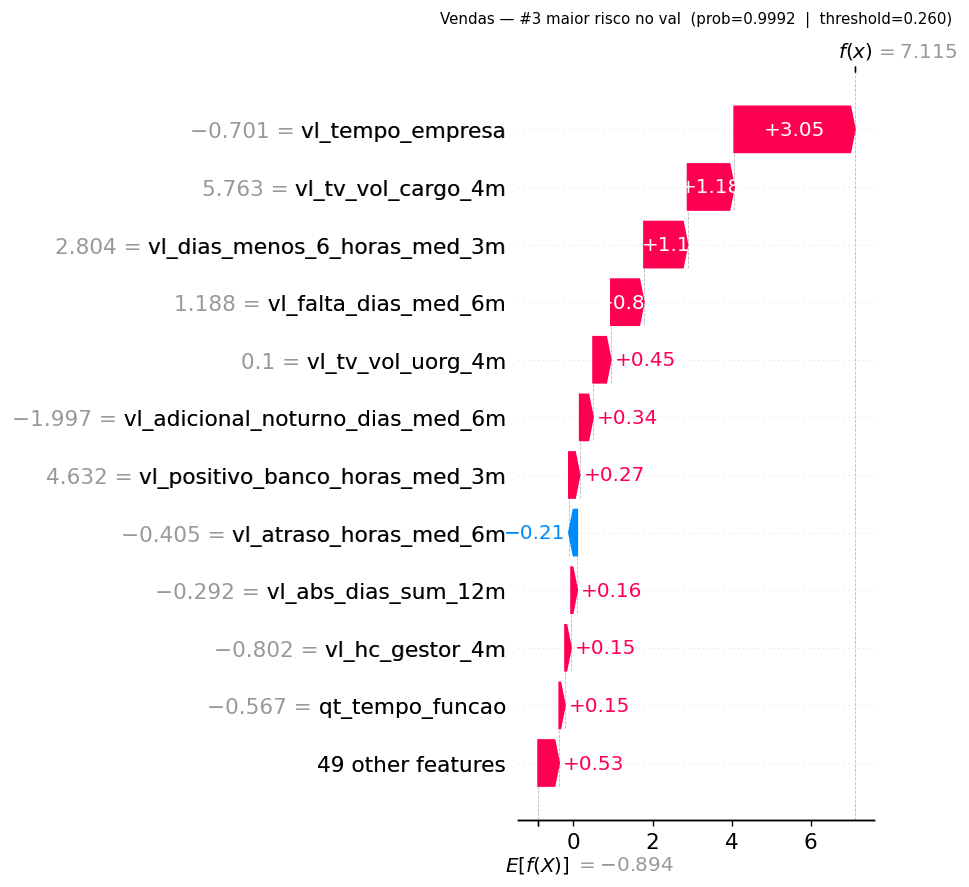

     ✓ Salvo: reports\shap\Vendas\waterfall_top3_risk.png

GRUPO: Transporte


  #1 maior risco  →  prob=0.9997  (ALTO)


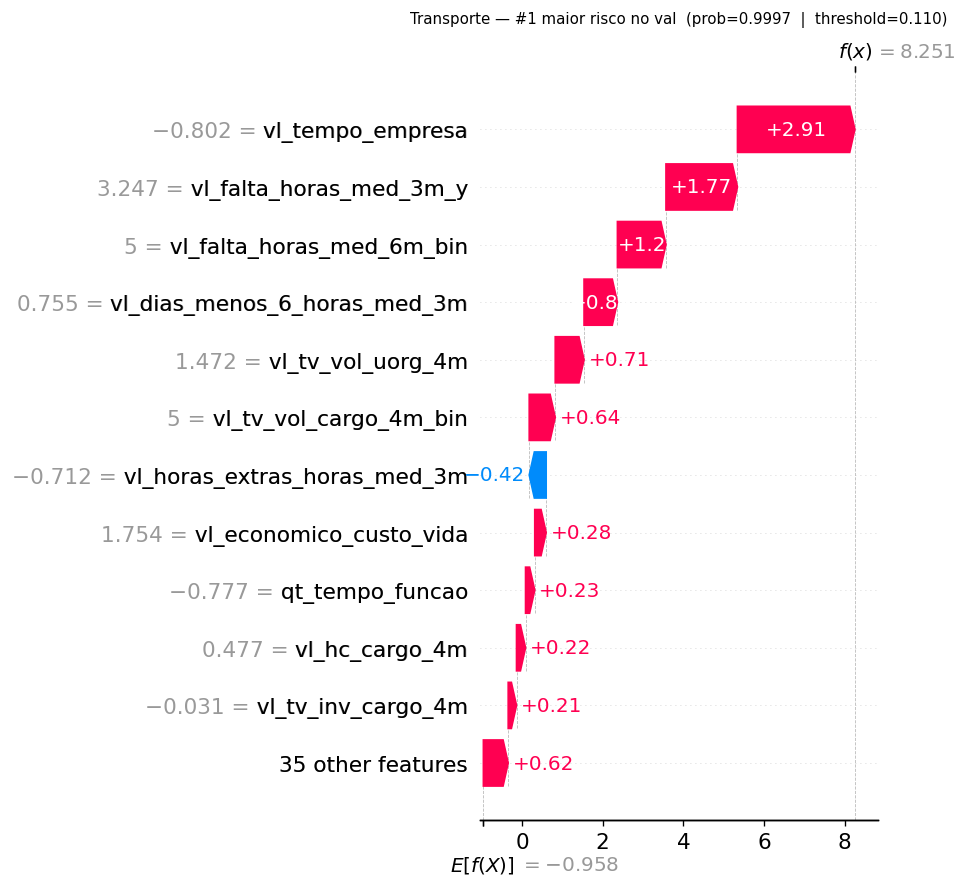

     ✓ Salvo: reports\shap\Transporte\waterfall_top1_risk.png
  #2 maior risco  →  prob=0.9994  (ALTO)


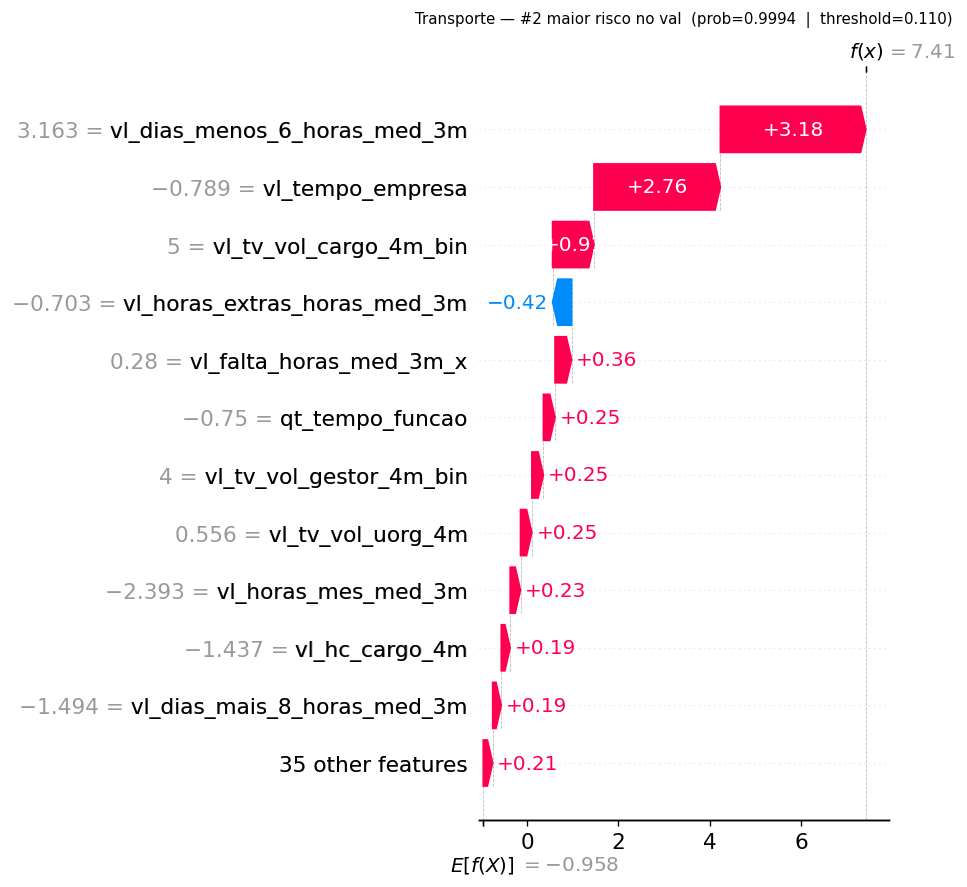

     ✓ Salvo: reports\shap\Transporte\waterfall_top2_risk.png
  #3 maior risco  →  prob=0.9993  (ALTO)


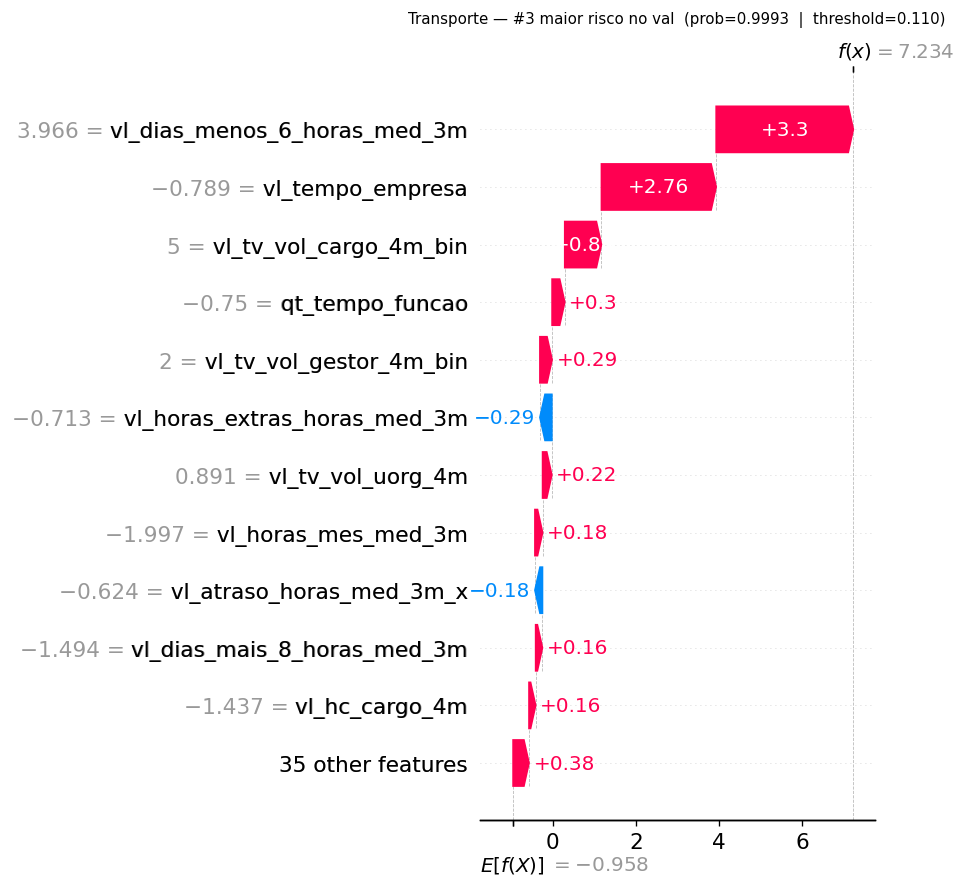

     ✓ Salvo: reports\shap\Transporte\waterfall_top3_risk.png

GRUPO: Fábrica
  #1 maior risco  →  prob=0.9824  (ALTO)


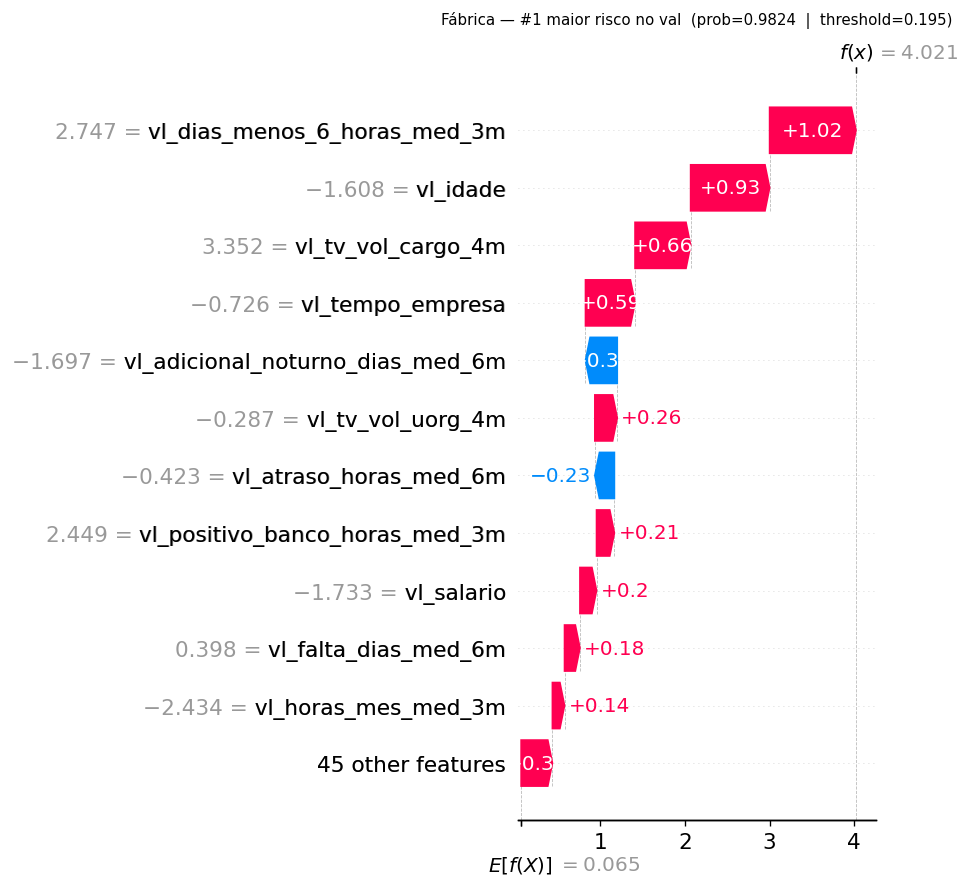

     ✓ Salvo: reports\shap\Fábrica\waterfall_top1_risk.png
  #2 maior risco  →  prob=0.9809  (ALTO)


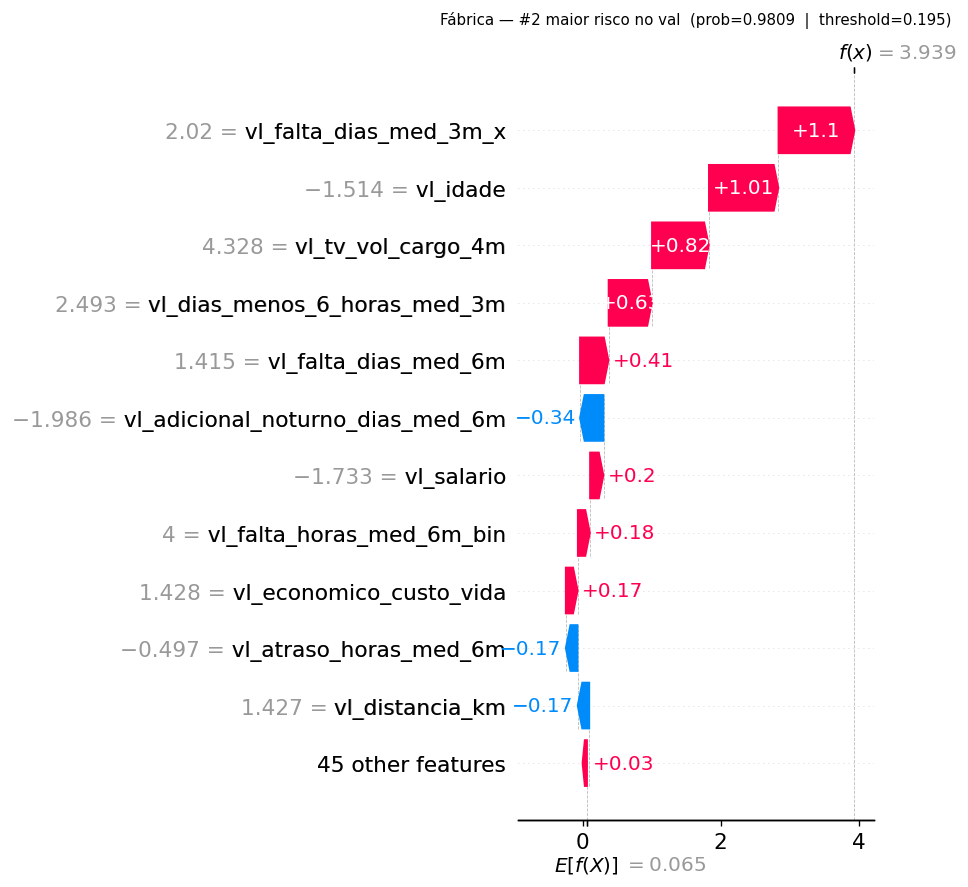

     ✓ Salvo: reports\shap\Fábrica\waterfall_top2_risk.png
  #3 maior risco  →  prob=0.9692  (ALTO)


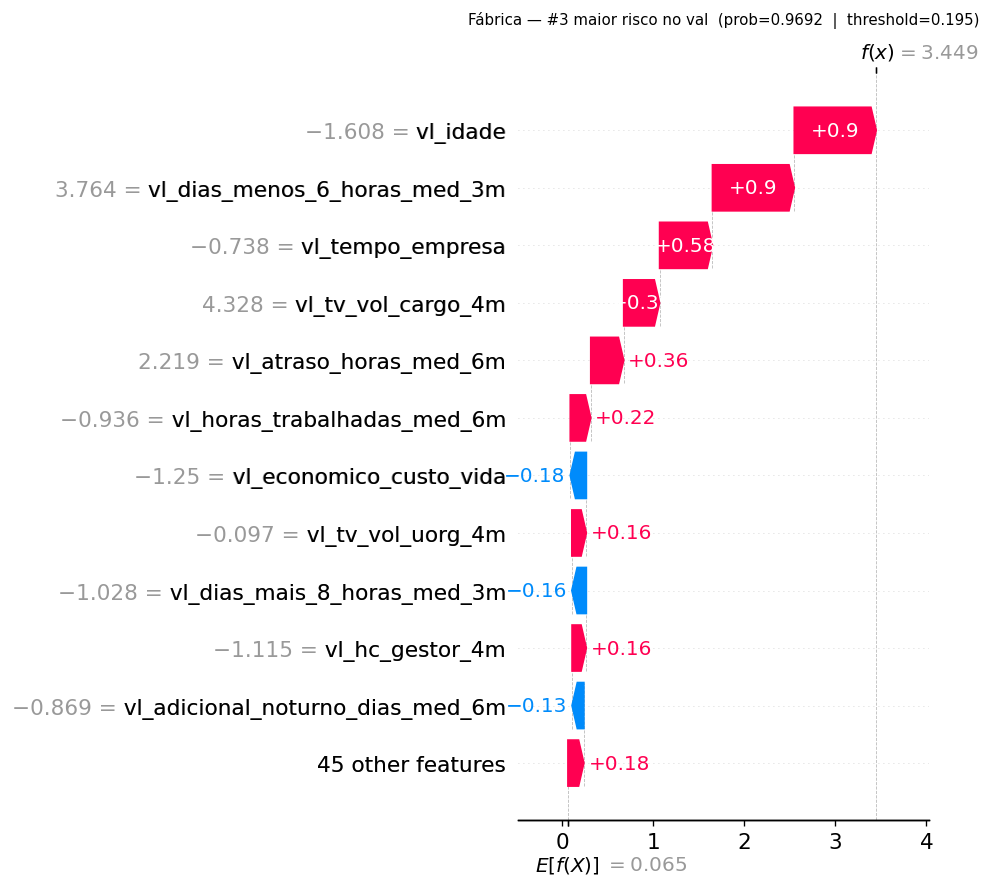

     ✓ Salvo: reports\shap\Fábrica\waterfall_top3_risk.png

✓ Waterfall concluído para todos os grupos


In [4]:
import json, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import shap
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
DATA_SPLITS  = PROJECT_ROOT / "data" / "processed" / "splits"
FS_DIR       = PROJECT_ROOT / "data" / "processed" / "feature_selection"
MODELS_DIR   = PROJECT_ROOT / "models"
SHAP_DIR     = PROJECT_ROOT / "reports" / "shap"
GRUPOS       = ["Vendas", "Transporte", "Fábrica"]
MAX_DISPLAY  = 12   # features no waterfall
TOP_N_RISK   = 3    # colaboradores de maior risco por grupo

for GRUPO in GRUPOS:
    print(f"\n{'='*65}")
    print(f"GRUPO: {GRUPO}")
    print('='*65)

    FEATURES = json.loads(
        (FS_DIR / GRUPO / "selected_features.json").read_text(encoding="utf-8")
    )["selected_features"]
    meta_05    = json.loads((MODELS_DIR / GRUPO / "model_metadata.json").read_text(encoding="utf-8"))
    meta_tuned = json.loads((MODELS_DIR / GRUPO / "tuning_metadata.json").read_text(encoding="utf-8"))
    COL_TARGET = meta_05["col_target"]
    threshold  = meta_tuned["threshold"]

    model  = joblib.load(MODELS_DIR / GRUPO / "best_model_tuned.joblib")
    df_val = pd.read_parquet(DATA_SPLITS / GRUPO / "val.parquet")
    X_val  = df_val[FEATURES].copy()

    proba       = model.predict_proba(X_val)[:, 1]
    top_indices = np.argsort(proba)[::-1][:TOP_N_RISK]   # os 3 de maior risco

    explainer = shap.TreeExplainer(model)

    for rank, idx in enumerate(top_indices, start=1):
        prob_i = proba[idx]
        nivel  = "ALTO" if prob_i >= threshold else "MÉDIO"
        print(f"  #{rank} maior risco  →  prob={prob_i:.4f}  ({nivel})")

        X_single  = X_val.iloc[[idx]]
        sv_single = explainer.shap_values(X_single)

        ev = explainer.expected_value
        if isinstance(sv_single, list):
            sv_s = sv_single[1][0]
            base = float(np.asarray(ev).flat[-1])
        elif isinstance(sv_single, np.ndarray) and sv_single.ndim == 3:
            sv_s = sv_single[0, :, 1]
            base = float(np.asarray(ev).flat[-1])
        else:
            sv_s = sv_single[0]
            base = float(ev) if np.isscalar(ev) else float(np.asarray(ev).flat[-1])

        single_exp = shap.Explanation(
            values        = sv_s,
            base_values   = base,
            data          = X_single.values[0],
            feature_names = FEATURES,
        )

        shap.plots.waterfall(single_exp, max_display=MAX_DISPLAY, show=False)
        plt.title(
            f"{GRUPO} — #{rank} maior risco no val  "
            f"(prob={prob_i:.4f}  |  threshold={threshold:.3f})",
            fontsize=9, pad=10,
        )
        plt.tight_layout()

        wf_path = SHAP_DIR / GRUPO / f"waterfall_top{rank}_risk.png"
        wf_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(wf_path, dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()
        print(f"     ✓ Salvo: {wf_path.relative_to(PROJECT_ROOT)}")

print(f"\n{'='*65}")
print("✓ Waterfall concluído para todos os grupos")
print('='*65)


## 4 · Drift Validação → Aplicação

Compara distribuições das **features selecionadas** entre validação (`base_features_val.parquet`) e aplicação (`base_features_apl.parquet`).  
Avalia também o deslocamento da **distribuição de scores** preditos entre as duas populações.

| Nível | KS statistic |
|---|---|
| Significativo | > 0,20 |
| Moderado | 0,10 – 0,20 |
| Estável | ≤ 0,10 |


Val gold  : (17101, 175)  |  Apl gold: (36421, 175)

GRUPO: Vendas


  Val  : 6,127 linhas  |  Apl: 13,093 linhas  |  60 features


  Drift  →  significativo=15  moderado=14  estável=31

                                     Feature       KS       JS           Nível
  ----------------------------------------------------------------------------
                        vl_falta_dias_med_6m   0.5125   0.3641   significativo
                          vl_tv_inv_cargo_4m   0.5034   0.1548   significativo
                              vl_hc_cargo_4m   0.4572   0.3937   significativo
              vl_positivo_banco_horas_med_3m   0.3160   0.0571   significativo
                 vl_horas_trabalhadas_med_6m   0.2986   0.0755   significativo
                          vl_tv_vol_cargo_4m   0.2827   0.1936   significativo
            vl_adicional_noturno_dias_med_6m   0.2766   0.0673   significativo
                      vl_falta_dias_med_3m_x   0.2508   0.0881   significativo
                 vl_atraso_dias_med_3m_y_bin   0.2395   0.0309   significativo
                           vl_tempo_promocao   0.2362   0.1333   significati


  Score val : mediana=0.1834  P25=0.0670  P75=0.4430
  Score apl : mediana=0.8206  P25=0.6936  P75=0.9052
  Shift mediana : 0.6372  ⚠ SHIFT > 0.10


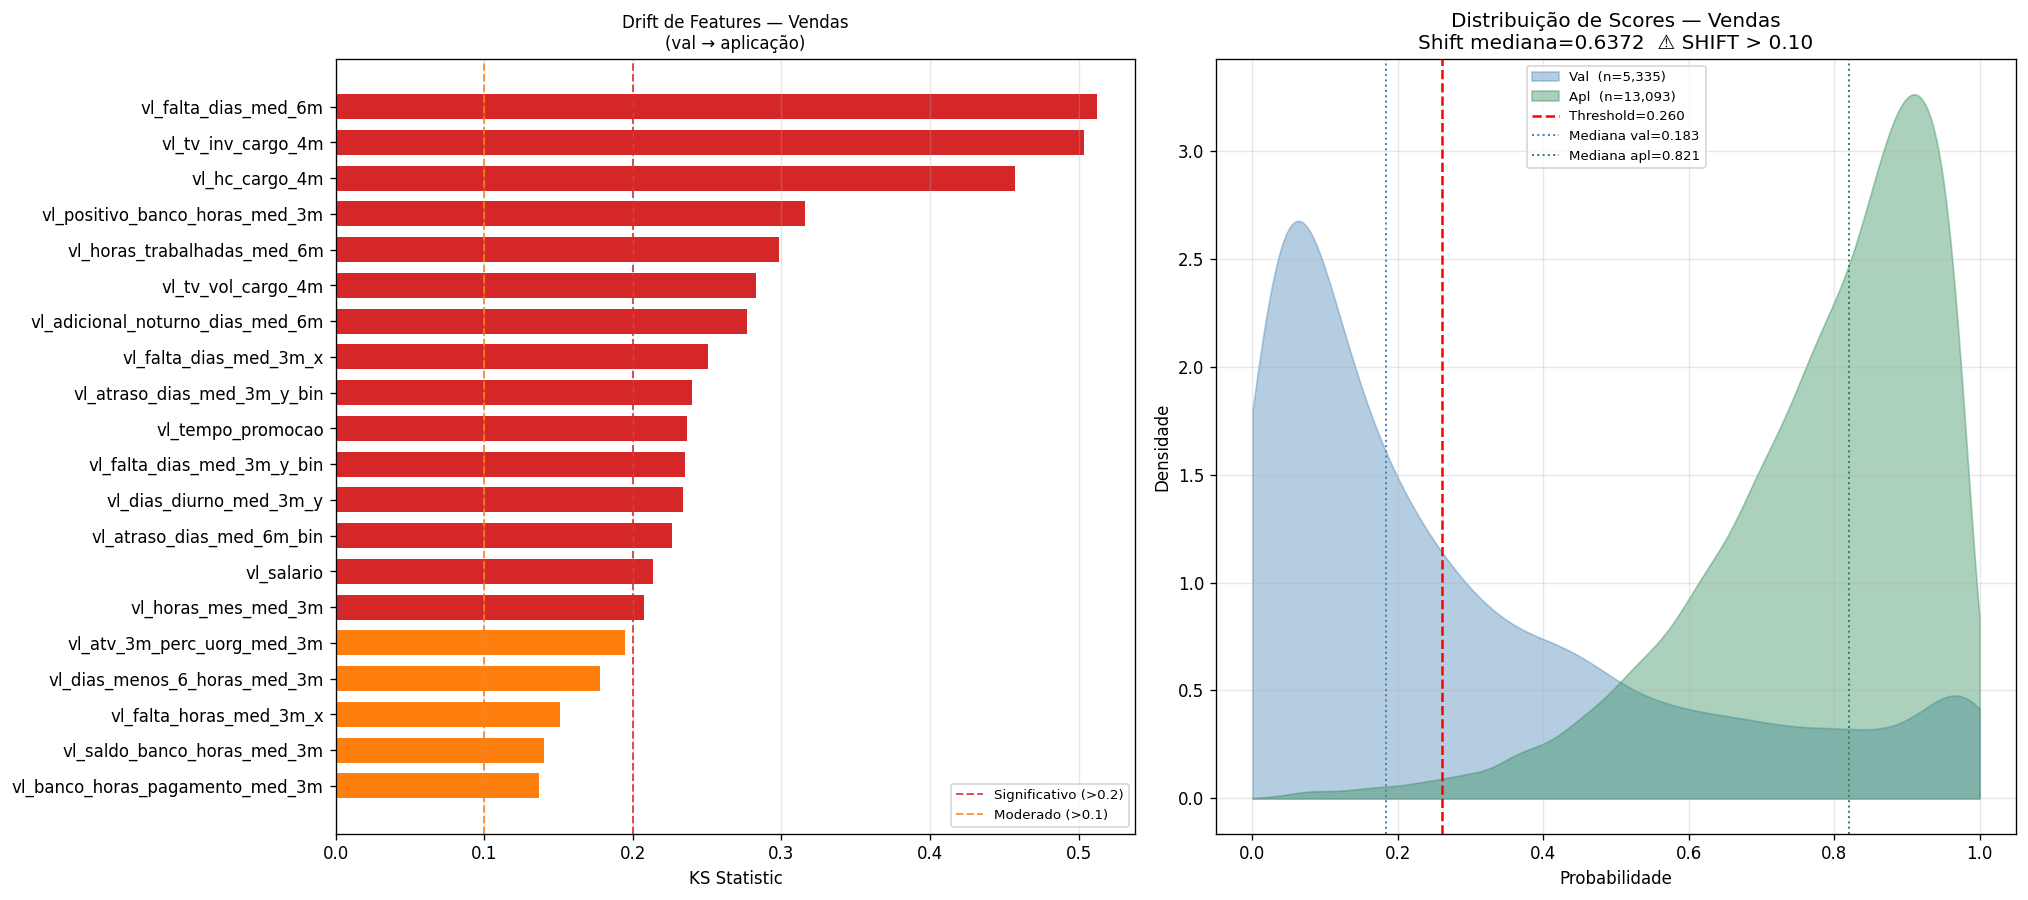

  ✓ Salvo: reports\figures\Vendas\drift_val_apl.png

GRUPO: Transporte
  Val  : 8,930 linhas  |  Apl: 18,803 linhas  |  46 features


  Drift  →  significativo=11  moderado=9  estável=26

                                     Feature       KS       JS           Nível
  ----------------------------------------------------------------------------
                        vl_falta_dias_med_6m   0.5196   0.3609   significativo
                           vl_tempo_promocao   0.4187   0.2704   significativo
                          vl_tv_inv_cargo_4m   0.3663   0.3110   significativo
            vl_adicional_noturno_dias_med_6m   0.3233   0.0788   significativo
                 vl_atraso_dias_med_3m_y_bin   0.2609   0.0407   significativo
                      vl_falta_dias_med_3m_x   0.2545   0.0873   significativo
                     vl_dias_diurno_med_3m_x   0.2252   0.0390   significativo
                 vl_dias_diurno_med_3m_y_bin   0.2109   0.0279   significativo
                 vl_horas_trabalhadas_med_6m   0.2075   0.0392   significativo
                              vl_hc_cargo_4m   0.2069   0.1411   significativ


  Score val : mediana=0.0331  P25=0.0113  P75=0.1309
  Score apl : mediana=0.9525  P25=0.8698  P75=0.9823
  Shift mediana : 0.9194  ⚠ SHIFT > 0.10


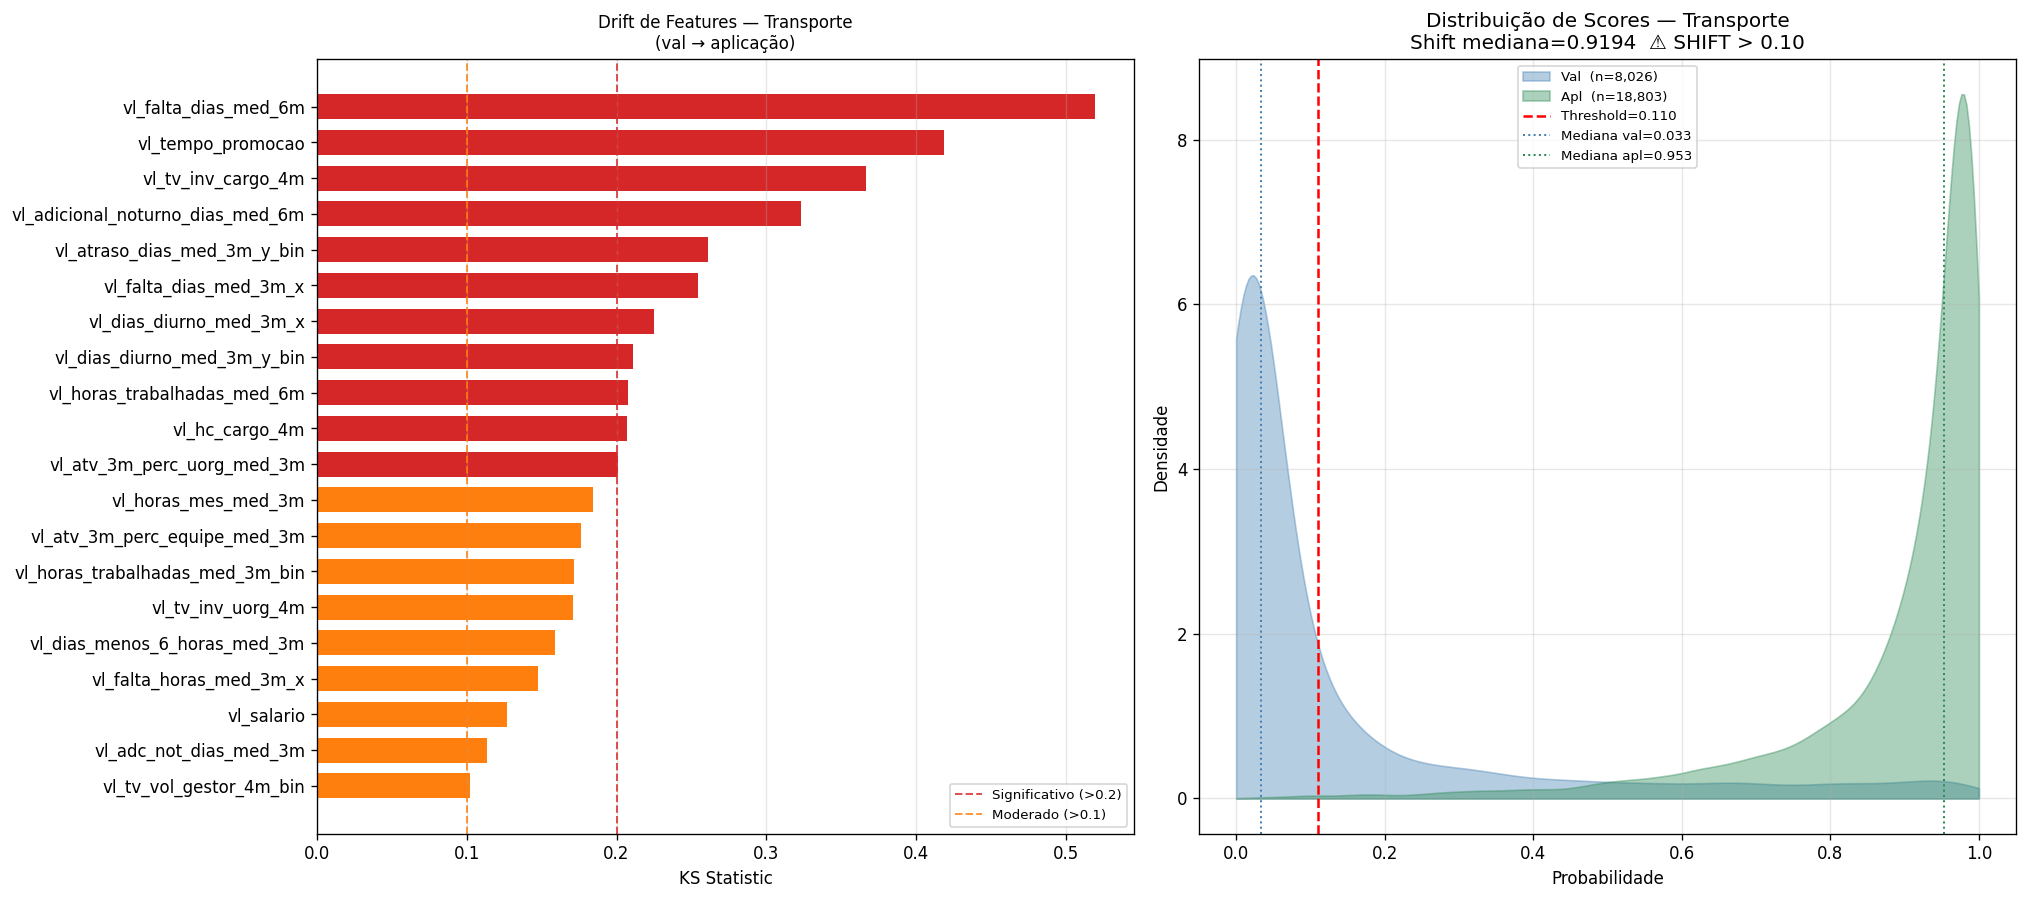

  ✓ Salvo: reports\figures\Transporte\drift_val_apl.png

GRUPO: Fábrica
  Val  : 2,044 linhas  |  Apl: 4,525 linhas  |  56 features


  Drift  →  significativo=7  moderado=15  estável=34

                                     Feature       KS       JS           Nível
  ----------------------------------------------------------------------------
                        vl_falta_dias_med_6m   0.5377   0.3194   significativo
                  vl_atv_3m_perc_uorg_med_3m   0.3117   0.1335   significativo
                           vl_tempo_promocao   0.3034   0.2304   significativo
                      vl_falta_dias_med_3m_x   0.2478   0.0863   significativo
                  vl_falta_dias_med_3m_y_bin   0.2370   0.0709   significativo
                          vl_tv_vol_cargo_4m   0.2218   0.0997   significativo
                vl_atv_3m_perc_equipe_med_3m   0.2072   0.0316   significativo
                           vl_tv_inv_uorg_4m   0.1917   0.1763        moderado
                 vl_horas_trabalhadas_med_6m   0.1889   0.0301        moderado
                              vl_hc_cargo_4m   0.1827   0.0482        moderad

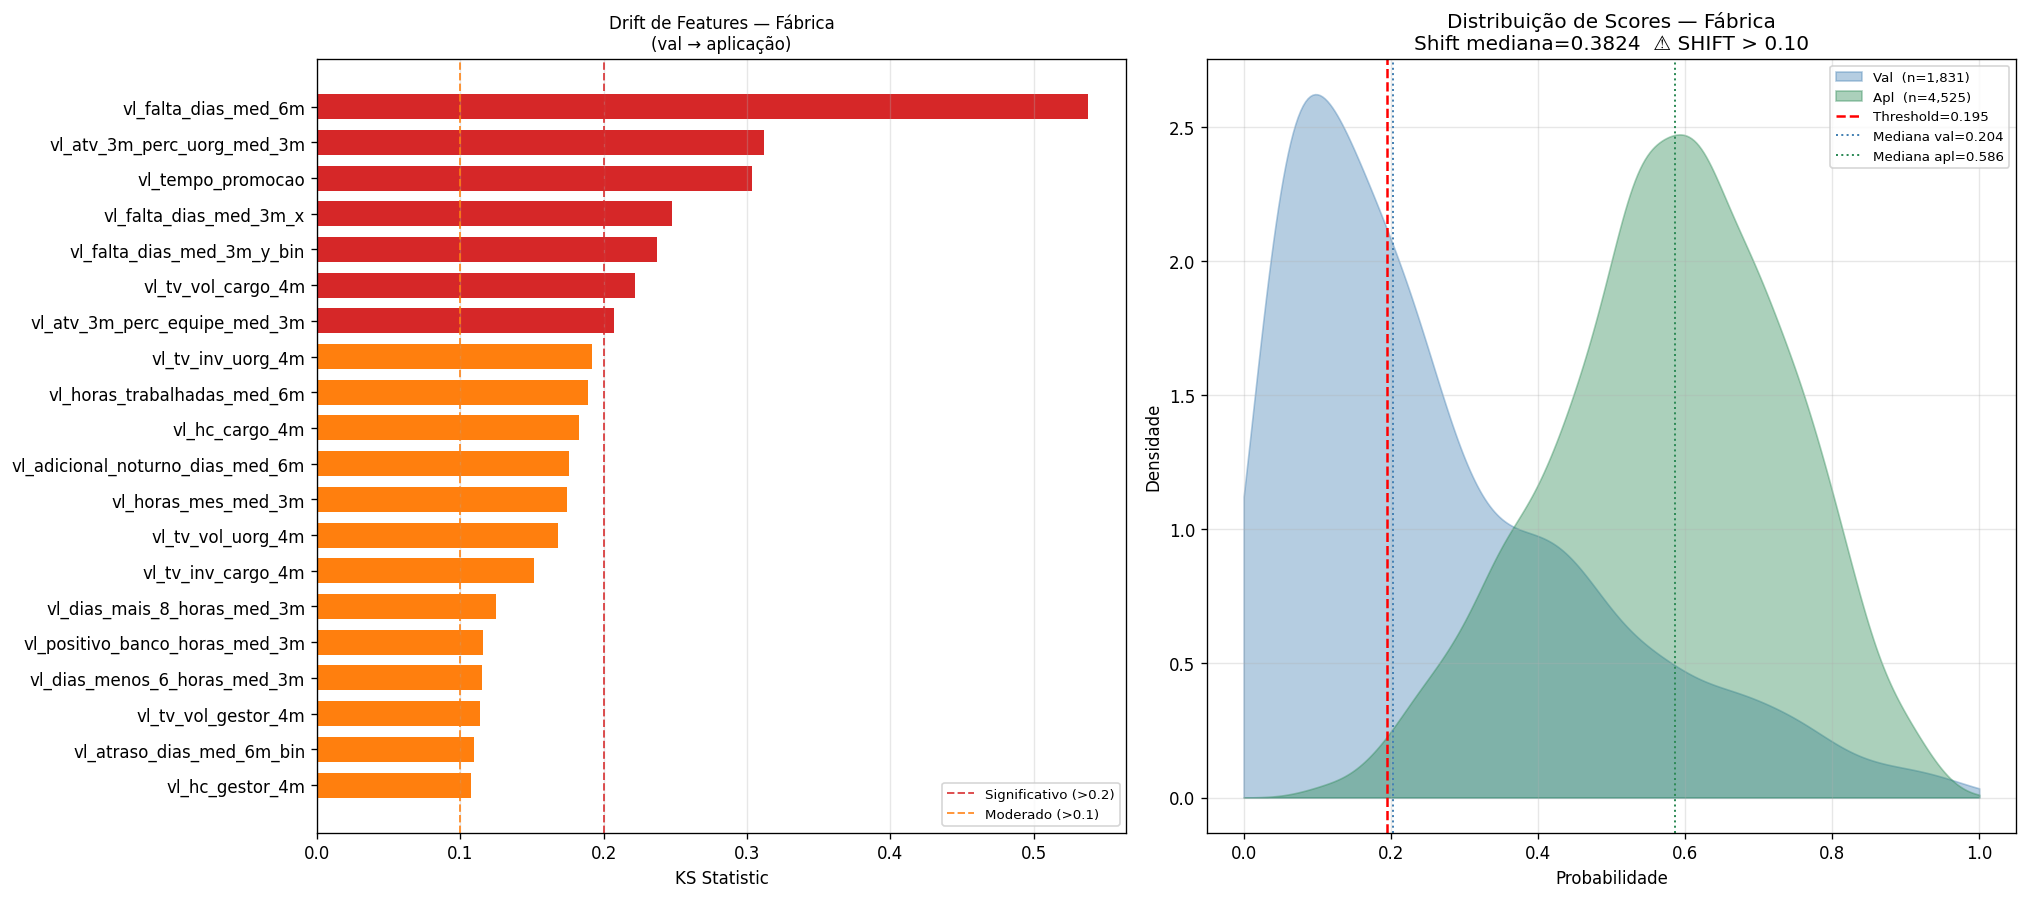

  ✓ Salvo: reports\figures\Fábrica\drift_val_apl.png

RESUMO CONSOLIDADO — Drift Val → Aplicação
nivel_drift  significativo  moderado  estável  total
grupo                                               
Fábrica                  7        15       34     56
Transporte              11         9       26     46
Vendas                  15        14       31     60


In [5]:
import json, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ks_2samp, gaussian_kde

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
GOLD_DIR     = PROJECT_ROOT / "data" / "gold"
DATA_SPLITS  = PROJECT_ROOT / "data" / "processed" / "splits"
FS_DIR       = PROJECT_ROOT / "data" / "processed" / "feature_selection"
MODELS_DIR   = PROJECT_ROOT / "models"
FIGURES_DIR  = PROJECT_ROOT / "reports" / "figures"
GRUPOS       = ["Vendas", "Transporte", "Fábrica"]
COL_GRUPO    = "ds_grupo"
KS_HIGH      = 0.20
KS_MOD       = 0.10


def _js_div(a: np.ndarray, b: np.ndarray, n_bins: int = 20) -> float:
    """Jensen-Shannon divergence via histograma (P1–P99)."""
    combined = np.concatenate([a, b])
    lo, hi = np.nanpercentile(combined, [1, 99])
    if lo >= hi:
        return 0.0
    bins = np.linspace(lo, hi, n_bins + 1)
    p = np.histogram(a, bins=bins, density=True)[0].astype(float) + 1e-10
    q = np.histogram(b, bins=bins, density=True)[0].astype(float) + 1e-10
    p /= p.sum(); q /= q.sum()
    m = 0.5 * (p + q)
    return float(np.clip(
        0.5 * (np.sum(p * np.log(p / m)) + np.sum(q * np.log(q / m))), 0, 1,
    ))


# ── Carregar bases gold (pré-scale) ─────────────────────────
df_val_all = pd.read_parquet(GOLD_DIR / "base_features_val.parquet")
df_apl_all = pd.read_parquet(GOLD_DIR / "base_features_apl.parquet")
print(f"Val gold  : {df_val_all.shape}  |  Apl gold: {df_apl_all.shape}")

all_records = []

for GRUPO in GRUPOS:
    print(f"\n{'='*65}")
    print(f"GRUPO: {GRUPO}")
    print('='*65)

    FEATURES = json.loads(
        (FS_DIR / GRUPO / "selected_features.json").read_text(encoding="utf-8")
    )["selected_features"]
    meta_tuned = json.loads((MODELS_DIR / GRUPO / "tuning_metadata.json").read_text(encoding="utf-8"))
    threshold  = meta_tuned["threshold"]

    df_v = df_val_all[df_val_all[COL_GRUPO] == GRUPO].copy()
    df_a = df_apl_all[df_apl_all[COL_GRUPO] == GRUPO].copy()

    # Interseção: features disponíveis em ambos os parquets
    feats = [f for f in FEATURES if f in df_v.columns and f in df_a.columns]
    missing = set(FEATURES) - set(feats)
    if missing:
        print(f"  ⚠ {len(missing)} feature(s) ausentes nos parquets gold (ignoradas): {list(missing)[:5]}...")

    print(f"  Val  : {len(df_v):,} linhas  |  Apl: {len(df_a):,} linhas  |  {len(feats)} features")

    # ── KS + JS por feature (distribuição pré-scale) ─────────
    drift_recs = []
    for feat in feats:
        a = df_v[feat].dropna().values.astype(float)
        b = df_a[feat].dropna().values.astype(float)
        if len(a) < 5 or len(b) < 5:
            continue
        ks_stat, ks_pval = ks_2samp(a, b)
        js = _js_div(a, b)
        nivel = (
            "significativo" if ks_stat > KS_HIGH
            else "moderado"  if ks_stat > KS_MOD
            else "estável"
        )
        drift_recs.append({
            "grupo": GRUPO, "feature": feat,
            "ks_stat": round(float(ks_stat), 4), "ks_pval": round(float(ks_pval), 4),
            "js_div": round(js, 4), "nivel_drift": nivel,
        })

    df_d = pd.DataFrame(drift_recs).sort_values("ks_stat", ascending=False)
    n_sig = (df_d["nivel_drift"] == "significativo").sum()
    n_mod = (df_d["nivel_drift"] == "moderado").sum()
    n_est = (df_d["nivel_drift"] == "estável").sum()
    print(f"  Drift  →  significativo={n_sig}  moderado={n_mod}  estável={n_est}")

    print(f"\n  {'Feature':>42}  {'KS':>7}  {'JS':>7}  {'Nível':>14}")
    print("  " + "-" * 76)
    for _, row in df_d.head(10).iterrows():
        print(f"  {row['feature']:>42}  {row['ks_stat']:>7.4f}  {row['js_div']:>7.4f}  {row['nivel_drift']:>14}")

    all_records.extend(drift_recs)

    # ── Comparação de scores (val.parquet já processado vs apl escalonada) ──
    model  = joblib.load(MODELS_DIR / GRUPO / "best_model_tuned.joblib")

    # Val: usar split diretamente (já escalado)
    df_val_split = pd.read_parquet(DATA_SPLITS / GRUPO / "val.parquet")
    X_val_s = df_val_split[[f for f in feats if f in df_val_split.columns]]
    proba_val = model.predict_proba(X_val_s)[:, 1]

    # Apl: aplicar o mesmo scaler treinado no treino
    scaler      = joblib.load(MODELS_DIR / GRUPO / "standard_scaler.joblib")
    scaler_cols = json.loads(
        (DATA_SPLITS / GRUPO / "scaler_cols.json").read_text(encoding="utf-8")
    )
    # Verificar cobertura de scaler_cols no df_a
    sc_missing = [c for c in scaler_cols if c not in df_a.columns]
    df_apl_g = df_a[feats].copy()

    if not sc_missing:
        # Aplicar scaler na base full do grupo, depois extrair só as feats
        scaled_arr = scaler.transform(df_a[scaler_cols])  # (n_rows, n_scaler_cols)
        sc_idx_map = {col: i for i, col in enumerate(scaler_cols)}
        for col in feats:
            if col in sc_idx_map:
                df_apl_g[col] = scaled_arr[:, sc_idx_map[col]]
    else:
        print(f"  ⚠ {len(sc_missing)} scaler_cols ausentes na apl — scaling omitido"
              f" ({model.__class__.__name__} é invariante a escala)")

    proba_apl = model.predict_proba(df_apl_g)[:, 1]

    med_shift  = abs(np.median(proba_apl) - np.median(proba_val))
    flag_shift = "⚠ SHIFT > 0.10" if med_shift > 0.10 else "✓ dentro esperado"
    print(f"\n  Score val : mediana={np.median(proba_val):.4f}  "
          f"P25={np.percentile(proba_val, 25):.4f}  P75={np.percentile(proba_val, 75):.4f}")
    print(f"  Score apl : mediana={np.median(proba_apl):.4f}  "
          f"P25={np.percentile(proba_apl, 25):.4f}  P75={np.percentile(proba_apl, 75):.4f}")
    print(f"  Shift mediana : {med_shift:.4f}  {flag_shift}")

    # ── Plot 1: barras de drift por feature (top 20) ─────────
    top20   = df_d.head(20).iloc[::-1].reset_index(drop=True)
    palette = {"significativo": "#d62728", "moderado": "#ff7f0e", "estável": "#2ca02c"}
    colors  = [palette[n] for n in top20["nivel_drift"]]

    fig, axes = plt.subplots(1, 2, figsize=(17, max(5, len(top20) * 0.33 + 1)))

    axes[0].barh(top20["feature"], top20["ks_stat"], color=colors, height=0.7)
    axes[0].axvline(KS_HIGH, color="#d62728", linestyle="--", linewidth=1.2, alpha=0.8,
                    label=f"Significativo (>{KS_HIGH})")
    axes[0].axvline(KS_MOD,  color="#ff7f0e", linestyle="--", linewidth=1.2, alpha=0.8,
                    label=f"Moderado (>{KS_MOD})")
    axes[0].set_xlabel("KS Statistic")
    axes[0].set_title(f"Drift de Features — {GRUPO}\n(val → aplicação)", fontsize=10)
    axes[0].legend(fontsize=8)
    axes[0].grid(axis="x", alpha=0.3)

    # ── Plot 2: KDE de scores ─────────────────────────────────
    x_grid  = np.linspace(0, 1, 300)
    kde_val = gaussian_kde(proba_val)(x_grid)
    kde_apl = gaussian_kde(proba_apl)(x_grid)

    axes[1].fill_between(x_grid, kde_val, alpha=0.4, color="steelblue",
                         label=f"Val  (n={len(proba_val):,})")
    axes[1].fill_between(x_grid, kde_apl, alpha=0.4, color="seagreen",
                         label=f"Apl  (n={len(proba_apl):,})")
    axes[1].axvline(threshold, color="red", linestyle="--", linewidth=1.5,
                    label=f"Threshold={threshold:.3f}")
    axes[1].axvline(np.median(proba_val), color="steelblue", linestyle=":", linewidth=1.2,
                    label=f"Mediana val={np.median(proba_val):.3f}")
    axes[1].axvline(np.median(proba_apl), color="seagreen",  linestyle=":", linewidth=1.2,
                    label=f"Mediana apl={np.median(proba_apl):.3f}")
    axes[1].set(xlabel="Probabilidade", ylabel="Densidade",
                title=f"Distribuição de Scores — {GRUPO}\nShift mediana={med_shift:.4f}  {flag_shift}")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fig_path = FIGURES_DIR / GRUPO / "drift_val_apl.png"
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  ✓ Salvo: {fig_path.relative_to(PROJECT_ROOT)}")

# ── Resumo consolidado ────────────────────────────────────────
print(f"\n{'='*65}")
print("RESUMO CONSOLIDADO — Drift Val → Aplicação")
print('='*65)
df_all = pd.DataFrame(all_records)
pivot  = df_all.groupby(["grupo", "nivel_drift"]).size().unstack(fill_value=0)
for col in ["significativo", "moderado", "estável"]:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[["significativo", "moderado", "estável"]]
pivot["total"] = pivot.sum(axis=1)
print(pivot.to_string())


## 5 · Resumo


In [6]:
df_shap_summary = pd.DataFrame(shap_summary)
print("\nResumo SHAP — top features por grupo:")
print(df_shap_summary.to_string(index=False))

print("\nArquivos salvos em reports/shap/{grupo}/:")
for grupo in GRUPOS:
    shap_files = [
        "summary_bar.png", "summary_beeswarm.png", "dependence_top3.png",
        "shap_values.npy", "shap_feature_importance.json",
        "waterfall_top1_risk.png", "waterfall_top2_risk.png", "waterfall_top3_risk.png",
    ]
    for fn in shap_files:
        p = SHAP_DIR / grupo / fn
        status = "✓" if p.exists() else "✗"
        print(f"  {status}  reports/shap/{grupo}/{fn}")

print("\nArquivos salvos em reports/figures/{grupo}/:")
for grupo in GRUPOS:
    p = PROJECT_ROOT / "reports" / "figures" / grupo / "drift_val_apl.png"
    status = "✓" if p.exists() else "✗"
    print(f"  {status}  reports/figures/{grupo}/drift_val_apl.png")



Resumo SHAP — top features por grupo:
     Grupo   Modelo  N_shap                        Top-1                        Top-2                      Top-3
    Vendas LightGBM    1000 vl_dias_menos_6_horas_med_3m             vl_tempo_empresa  vl_falta_horas_med_6m_bin
Transporte LightGBM    1000 vl_horas_extras_horas_med_3m vl_dias_menos_6_horas_med_3m vl_atraso_horas_med_6m_bin
   Fábrica  XGBoost    1000            vl_tempo_promocao                     vl_idade     vl_atraso_horas_med_6m

Arquivos salvos em reports/shap/{grupo}/:
  ✓  reports/shap/Vendas/summary_bar.png
  ✓  reports/shap/Vendas/summary_beeswarm.png
  ✓  reports/shap/Vendas/dependence_top3.png
  ✓  reports/shap/Vendas/shap_values.npy
  ✓  reports/shap/Vendas/shap_feature_importance.json
  ✓  reports/shap/Vendas/waterfall_top1_risk.png
  ✓  reports/shap/Vendas/waterfall_top2_risk.png
  ✓  reports/shap/Vendas/waterfall_top3_risk.png
  ✓  reports/shap/Transporte/summary_bar.png
  ✓  reports/shap/Transporte/summary_beeswarm.p